In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from pysheds.grid import Grid
import mplleaflet
# %matplotlib inline

# Create the frid
grid = Grid.from_raster('../Rst/20190109125130_1063922483.tif')
# Read the DEM
dem = grid.read_raster('../Rst/20190109125130_1063922483.tif')

# Visualizar el DEM
def plotFigure(data, label, cmap=None):
    plt.figure(figsize=(8, 6))
    plt.imshow(data, cmap=cmap)
    plt.colorbar(label=label)
    plt.grid()
    

def processDEM(grid, dem, show_plots=True):
    """
    Procesa un DEM para detectar y corregir depresiones, pozos y zonas planas.

    Parámetros:
    - grid: Objeto Grid de pysheds.
    - dem: Array numpy del modelo de elevación.
    - show_plots: Si True, muestra una figura con los resultados.

    Retorna:
    - fixed_dem: DEM corregido.
    """
    # Asegurar tipo float64 y definir nodata
    dem_float = dem.astype(np.float64)
    dem_float.nodata = np.nan  # Esto es simbólico, pysheds usa Raster con .nodata

    # Detectar y corregir depresiones
    depressions = grid.detect_depressions(dem_float)
    undepressed_dem = grid.fill_depressions(dem_float)
    no_depressions = grid.detect_depressions(undepressed_dem)

    # Detectar y corregir pits
    pits = grid.detect_pits(undepressed_dem)
    unpitted_dem = grid.fill_pits(undepressed_dem)
    no_pits = grid.detect_pits(unpitted_dem)

    # Detectar y corregir flats
    flats = grid.detect_flats(unpitted_dem)
    fixed_dem = grid.resolve_flats(unpitted_dem)
    no_flats = grid.detect_flats(fixed_dem)

    if show_plots:
        fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 12))
        titles = ['Depressions', 'No Depressions', 'Pits', 'No Pits', 'Flats', 'No Flats']
        datasets = [depressions, no_depressions, pits, no_pits, flats, no_flats]

        for ax, title, data in zip(axes.flat, titles, datasets):
            ax.imshow(data, cmap='viridis')
            ax.set_title(title)
            ax.axis('off')
            ax.grid(False)

        plt.tight_layout()
        plt.show()

    return fixed_dem


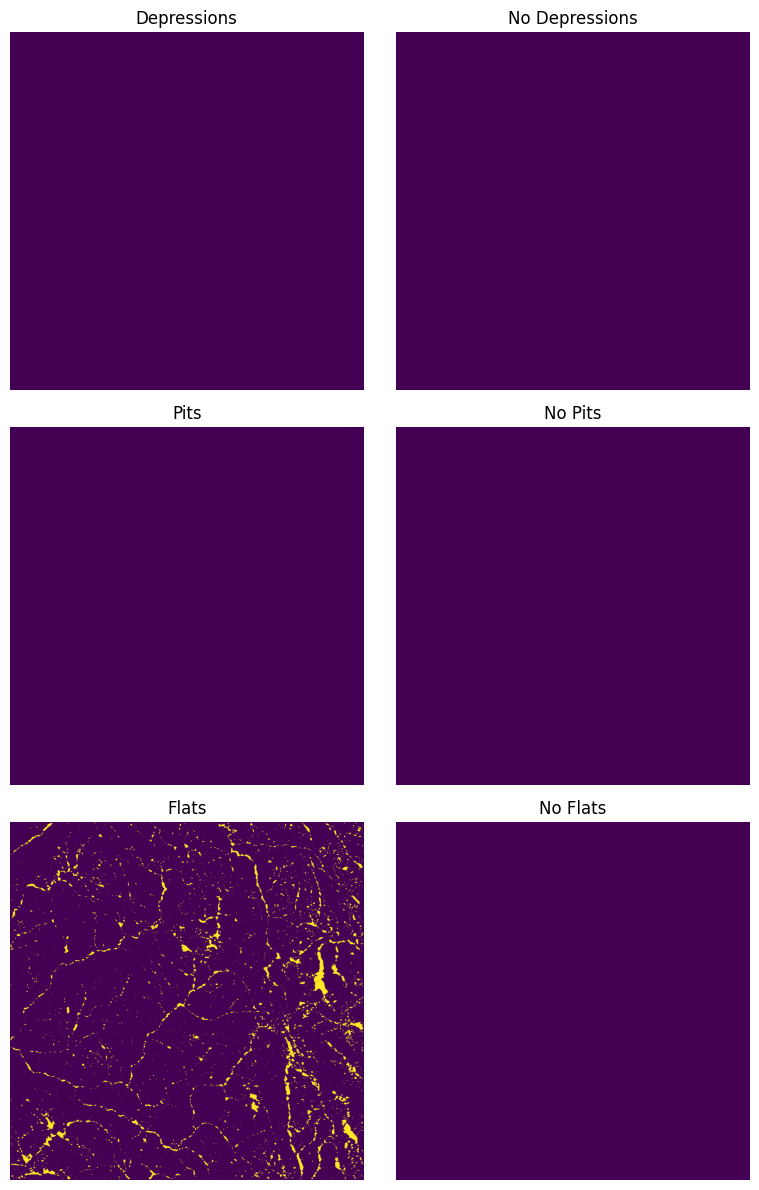

In [2]:
fixed_dem = processDEM(grid, dem, show_plots=True)
flats = grid.detect_flats(fixed_dem)

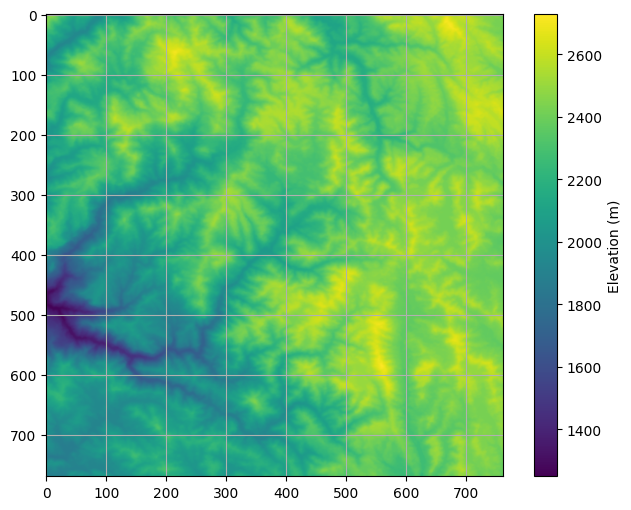

In [3]:
# Acceder a los datos del DEM correctamente
plotFigure(fixed_dem[:-1, :-1], 'Elevation (m)')

In [4]:
# Acceder a los datos del DEM corregido
fixed_dem.viewfinder

'affine' : Affine(0.00027777777777799565, 0.0, -107.99263888888889,
       0.0, -0.00027777777777799565, 27.97902777777889)
'shape' : (771, 762)
'nodata' : nan
'crs' : <Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

'mask' : array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(771, 762))

Check accumulation since it needs the LogNorm to see

In [5]:
# Determine D8 flow directions from DEM
# ----------------------
    
# Compute flow directions
# -------------------------------------
fdir = grid.flowdir(fixed_dem)

# Calculate flow accumulation
# --------------------------
acc = grid.accumulation(fdir)


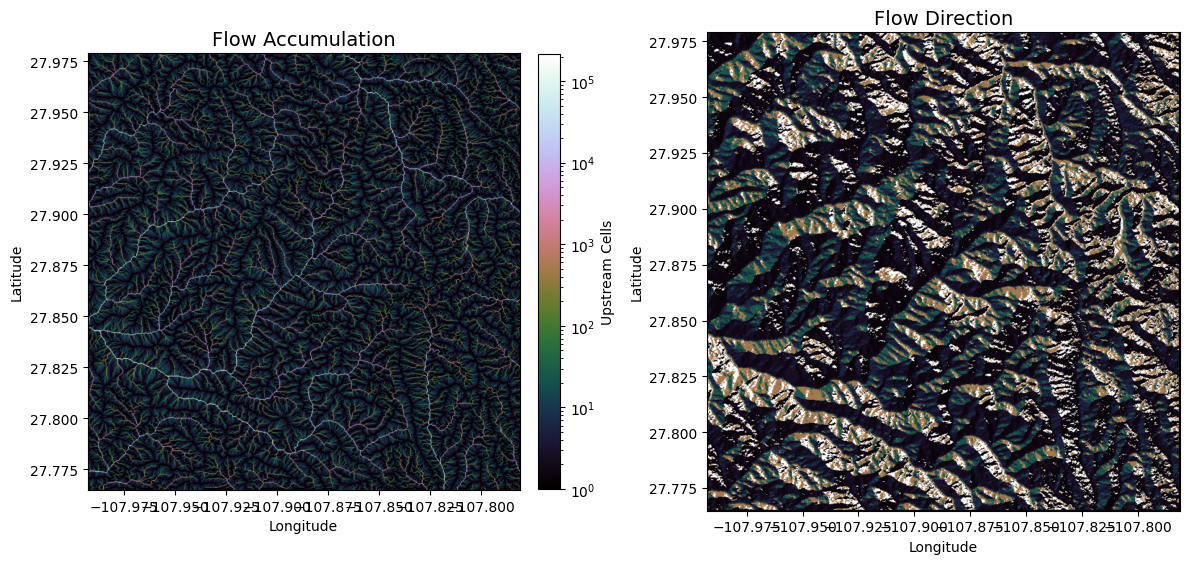

In [6]:
# Crear la figura con 2 columnas
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
fig.patch.set_alpha(0)

# Primer subplot: Flow Accumulation
ax1 = axes[0]
im1 = ax1.imshow(acc, extent=grid.extent, zorder=2,
                 cmap='cubehelix',
                 norm=colors.LogNorm(1, acc.max()),
                 interpolation='bilinear')
ax1.set_title('Flow Accumulation', size=14)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(im1, ax=ax1, label='Upstream Cells', fraction=0.046, pad=0.04)
ax1.grid(True)

# Segundo subplot: Flow Direction
ax2 = axes[1]
im2 = ax2.imshow(fdir, extent=grid.extent, zorder=2,
                 cmap='cubehelix',
                 interpolation='bilinear')
ax2.set_title('Flow Direction', size=14)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
# plt.colorbar(im2, ax=ax2, label='Flow Direction')
ax2.grid(True)

# Ajustar el diseño
plt.tight_layout()
plt.show()


In [7]:
acc

Raster([[ 1.,  1.,  1., ...,  1.,  1.,  2.],
        [ 3.,  2.,  2., ...,  1.,  1.,  2.],
        [ 6.,  3.,  3., ...,  4.,  1.,  2.],
        ...,
        [ 8., 12.,  5., ...,  2.,  5.,  6.],
        [21.,  1.,  1., ...,  5.,  1.,  2.],
        [22.,  2.,  2., ...,  6.,  1.,  1.]], shape=(771, 762))

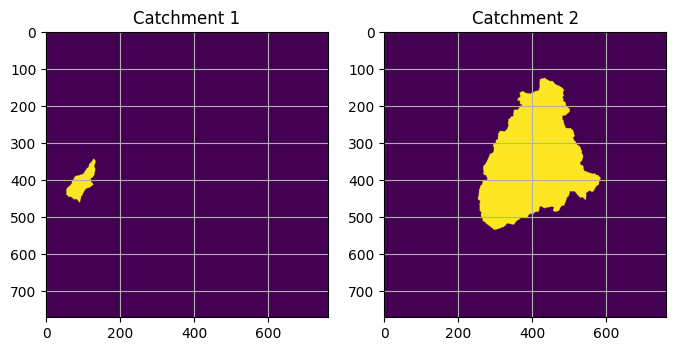

In [8]:
# Delineate a catchment
# ---------------------
def get_catchment(grid, x, y):
    """
    Delineate a catchment area from a given point (x, y) on the grid.

    Parameters:
    - grid: Grid object from pysheds.
    - x: Longitude of the pour point.
    - y: Latitude of the pour point.

    Returns:
    - catchment: Array representing the catchment area.
    """
    # Snap pour point to high accumulation cell
    x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))

    # Delineate the catchment
    catchment = grid.catchment(x=x_snap, y=y_snap, fdir=fdir)

    return catchment
# Specify pour point
x, y = -107.975, 27.850

catch = get_catchment(grid, x, y)

# Specify pour point
x2, y2 = -107.91663,27.83479

catch2 = get_catchment(grid, x2, y2)


plt.figure(figsize=(8, 4))

# Primer subplot: 
plt.subplot(1, 2, 1)
plt.imshow(catch)
plt.title('Catchment 1')
plt.grid(True)

# Segundo subplot: 
plt.subplot(1, 2, 2)
plt.imshow(catch2)
plt.title('Catchment 2')
plt.grid(True)


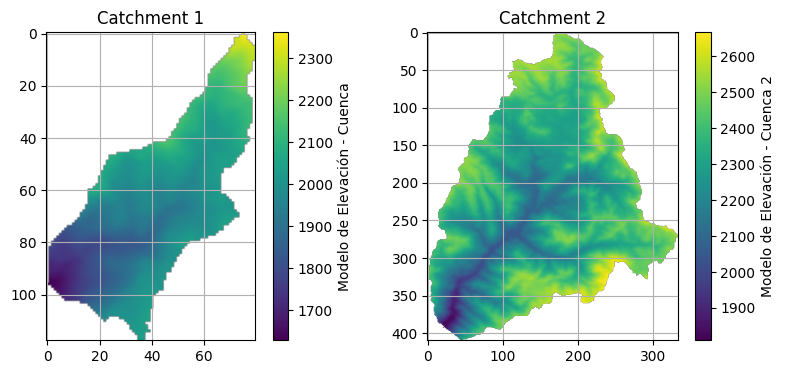

In [9]:
# Recortar el DEM a la cuenca
grid.clip_to(catch)
# Extraer los datos del DEM recortado
dem_catchment = grid.view(fixed_dem, nodata=np.nan)

grid.viewfinder = fixed_dem.viewfinder
grid.clip_to(catch2)
dem_catchment2 = grid.view(fixed_dem, nodata=np.nan)

plt.figure(figsize=(10, 4))

# Primer subplot: 
plt.subplot(1, 2, 1)
plt.imshow(dem_catchment)
plt.title('Catchment 1')
plt.colorbar(label='Modelo de Elevación - Cuenca')
plt.grid(True)

# Segundo subplot: 
plt.subplot(1, 2, 2)
plt.imshow(dem_catchment2)
plt.title('Catchment 2')
plt.colorbar(label='Modelo de Elevación - Cuenca 2')
plt.grid(True)

In [10]:
#export selected raster
grid.to_raster(dem_catchment2, '../Output/clippedCatchmentElevations.tif')

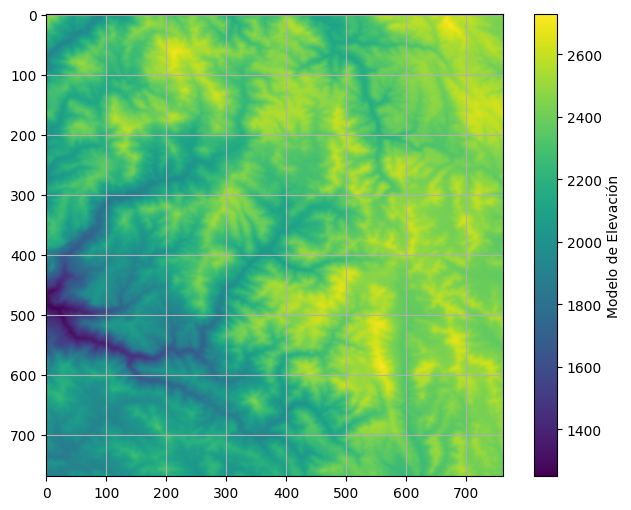

In [11]:
plotFigure(fixed_dem[:-1, :-1], 'Modelo de Elevación', cmap='viridis')

In [12]:
dem_catchment

Raster([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(118, 80))

In [13]:
catch

Raster([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(771, 762))

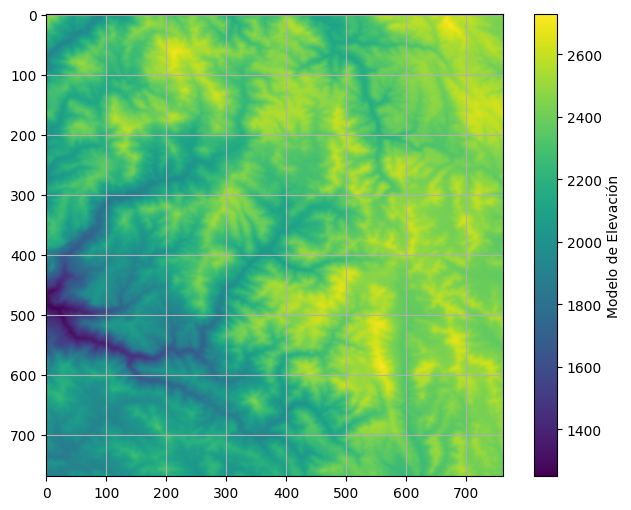

In [14]:
grid.viewfinder = fixed_dem.viewfinder
plotFigure(fixed_dem[:-1, :-1], 'Modelo de Elevación')

In [15]:
threshold = 1000
true_count = (acc > threshold).sum()
print(true_count, "of", acc.size, "cells are greater than", threshold)

9949 of 587502 cells are greater than 1000


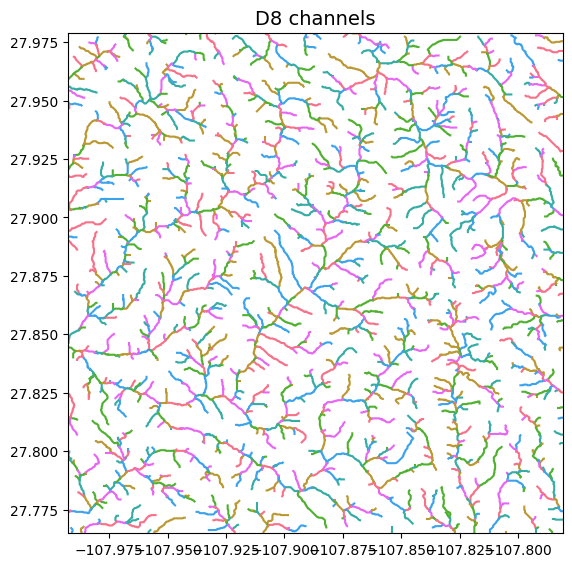

In [16]:
# Extract river network
# ---------------------
import seaborn as sns
branches = grid.extract_river_network(fdir, acc > 150)
sns.set_palette('husl')
fig, ax = plt.subplots(figsize=(8.5,6.5))

plt.xlim(grid.bbox[0], grid.bbox[2])
plt.ylim(grid.bbox[1], grid.bbox[3])
ax.set_aspect('equal')

for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])
    
_ = plt.title('D8 channels', size=14)

Text(0.5, 1.0, 'Flow Distance')

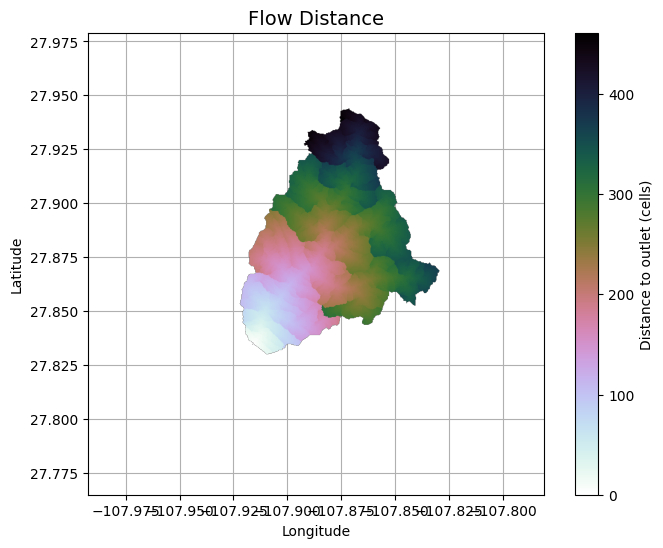

In [17]:
# Calculate distance to outlet from each cell
# -------------------------------------------
dist = grid.distance_to_outlet(x=x2, y=y2, fdir=fdir,
                               xytype='coordinate')
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(dist, extent=grid.extent, zorder=2,
               cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Distance to outlet (cells)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Distance', size=14)

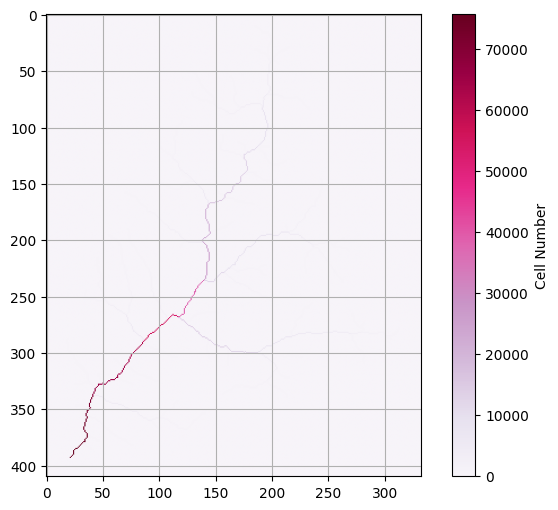

In [18]:
# Compute flow directions
# -------------------------------------

grid.clip_to(catch2)

subfdir = grid.flowdir(dem_catchment2)

# Calculate flow accumulation
# --------------------------
subbacc = grid.accumulation(subfdir)

plotFigure(subbacc,"Cell Number",'PuRd')

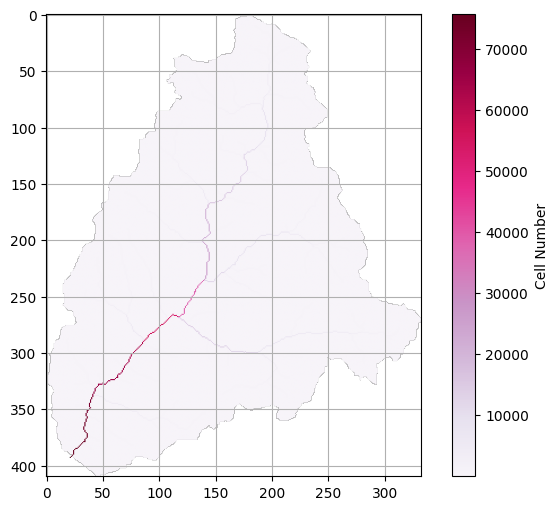

In [19]:
accView = grid.view(subbacc, nodata=np.nan)
plotFigure(accView,"Cell Number",'PuRd')

Text(0.5, 1.0, 'Cell Number with Max Accumulation')

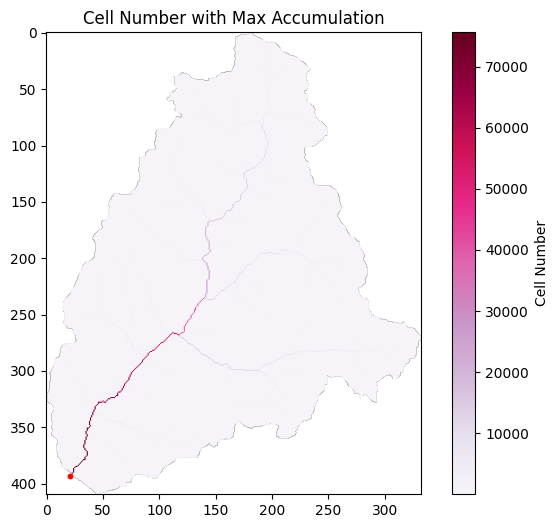

In [20]:
max_acc = subbacc.max()
max_acc
# Coordinates of the cell with maximum flow accumulation
max_coords = np.unravel_index(np.argmax(subbacc), subbacc.shape)

# Add the coordinates to the plot accview
plt.figure(figsize=(8, 6))
plt.imshow(accView, cmap='PuRd')
plt.colorbar(label='Cell Number')
plt.scatter(max_coords[1], max_coords[0], color='red', marker='o', s=10, label='Max Accumulation')
plt.title('Cell Number with Max Accumulation')

#  PENDIENTE EXTRAER RIO

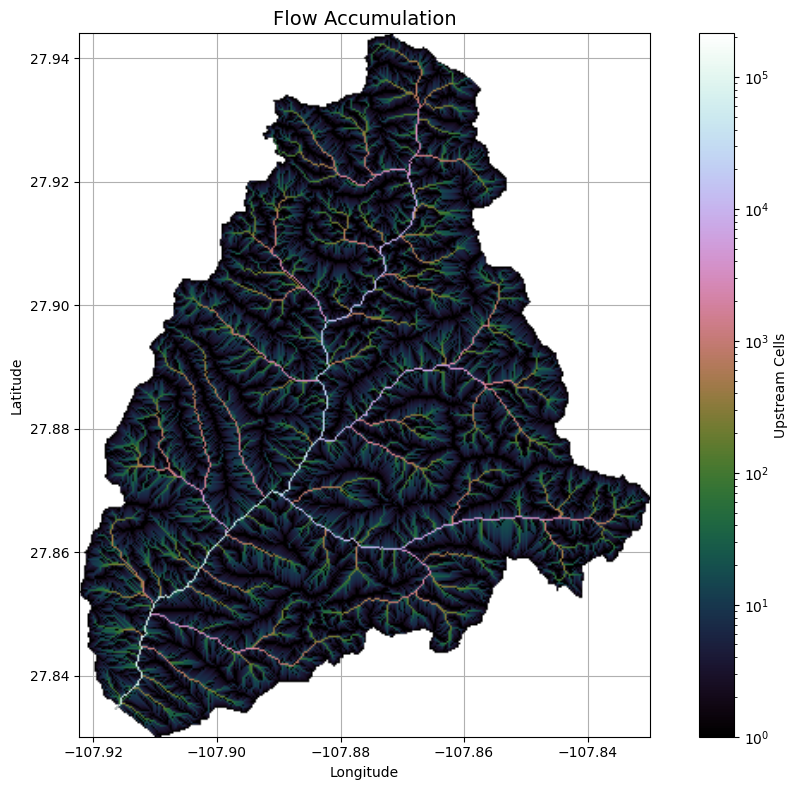

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_alpha(0)

im = ax.imshow(subbacc, extent=grid.extent, zorder=2,
               cmap='cubehelix',
               norm=colors.LogNorm(1, acc.max()),
               interpolation='bilinear')

plt.colorbar(im, ax=ax, label='Upstream Cells')
plt.title('Flow Accumulation', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


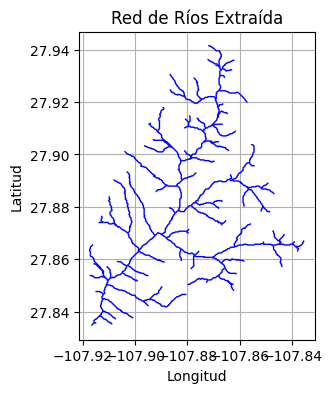

In [22]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Crear máscara de acumulación
stream_mask = acc > 200

# Extraer red de ríos
streams = grid.extract_river_network(fdir, mask=stream_mask)

# Convertir a GeoDataFrame para visualizar
gdf_streams = gpd.GeoDataFrame.from_features(streams["features"])

# Visualizar
fig, ax = plt.subplots(figsize=(6, 4))
gdf_streams.plot(ax=ax, color='blue', linewidth=1)
ax.set_title("Red de Ríos Extraída")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.grid(True)
plt.show()


In [23]:
streams

{"features": [{"geometry": {"coordinates": [[-107.872083, 27.941528], [-107.871806, 27.941528], [-107.871528, 27.941528], [-107.87125, 27.94125], [-107.870972, 27.94125], [-107.870694, 27.940972], [-107.870417, 27.940694], [-107.870139, 27.940694], [-107.869861, 27.940417], [-107.869583, 27.940139], [-107.869306, 27.939861], [-107.869028, 27.939583], [-107.86875, 27.939583], [-107.868472, 27.939583], [-107.868194, 27.939583], [-107.867917, 27.939583], [-107.867639, 27.939306], [-107.867639, 27.939028], [-107.867361, 27.93875], [-107.867361, 27.938472], [-107.867083, 27.938194], [-107.867083, 27.937917], [-107.867083, 27.937639], [-107.867083, 27.937361], [-107.867361, 27.937083], [-107.867361, 27.936806], [-107.867639, 27.936528], [-107.867639, 27.93625], [-107.867917, 27.935972], [-107.867917, 27.935694], [-107.867917, 27.935417], [-107.867917, 27.935139], [-107.867917, 27.934861], [-107.867917, 27.934583], [-107.867917, 27.934306], [-107.867917, 27.934028], [-107.867639, 27.93375], [

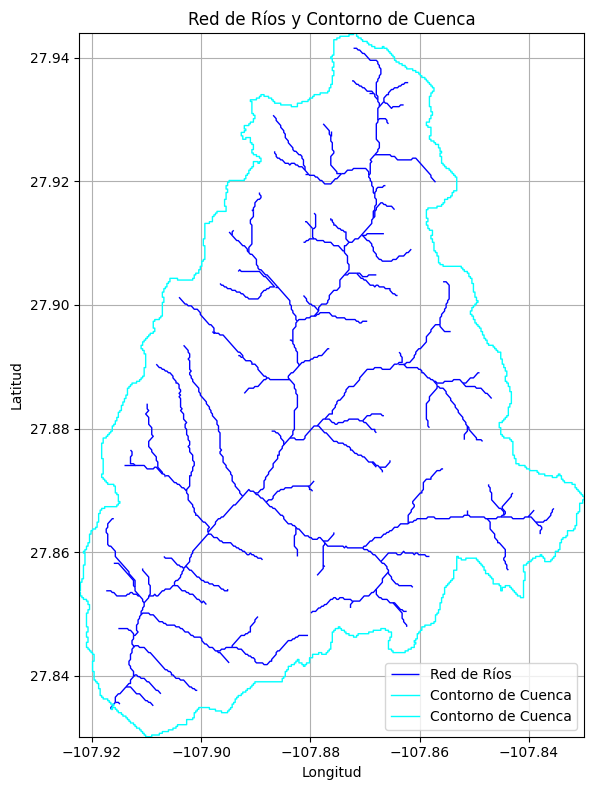

In [24]:
# Continuación: añadir contorno de cuenca a la visualización existente
import json

# 3. Guardar como GeoJSON correctamente
with open('../Output/streams_WGS84.geojson', 'w', encoding='utf-8') as f:
    json.dump(streams, f)


# 4. Cargar red de ríos con geopandas
streamNet = gpd.read_file('../Output/streams_WGS84.geojson')
streamNet.set_crs(epsg=4326, inplace=True)


# Extraer contorno de la cuenca
shapes = grid.polygonize()

# Crear nueva figura
fig, ax = plt.subplots(figsize=(10, 8))

# Dibujar red de ríos
streamNet.plot(ax=ax, color='blue', linewidth=1, label='Red de Ríos')

# Dibujar contorno de cuenca
for shape, _ in shapes:
    coords = np.asarray(shape['coordinates'][0])
    ax.plot(coords[:, 0], coords[:, 1], color='cyan', linewidth=1, label='Contorno de Cuenca')

# Configuración del gráfico
ax.set_xlim(grid.bbox[0], grid.bbox[2])
ax.set_ylim(grid.bbox[1], grid.bbox[3])
ax.set_title('Red de Ríos y Contorno de Cuenca')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
import folium

# Centrar el mapa en el primer segmento de río
center = streamNet.geometry[0].centroid.coords[0][::-1]  # (lat, lon)
m = folium.Map(location=center, zoom_start=13, tiles='Esri.WorldImagery')

# Añadir la red de ríos
folium.GeoJson(
    streamNet,
    name='Red de Ríos',
    style_function=lambda x: {'color': 'blue', 'weight': 2}
).add_to(m)

# Añadir contorno de cuenca
for shape, _ in shapes:
    folium.GeoJson(
        data=shape,
        name='Contorno de Cuenca',
        style_function=lambda x: {'color': 'cyan', 'weight': 2, 'fillOpacity': 0}
    ).add_to(m)

# Añadir control de capas
folium.LayerControl().add_to(m)

# Mostrar el mapa
m


<Axes: title={'center': 'Catchment boundary (vector)'}>

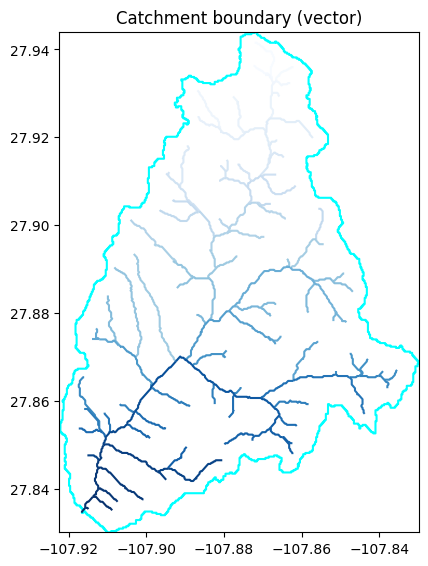

In [26]:
# The polygonize argument defaults to the grid mask when no arguments are supplied
shapes = grid.polygonize()

# Plot catchment boundaries
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for shape in shapes:
    coords = np.asarray(shape[0]['coordinates'][0])
    ax.plot(coords[:,0], coords[:,1], color='cyan')
    
ax.set_xlim(grid.bbox[0], grid.bbox[2])
ax.set_ylim(grid.bbox[1], grid.bbox[3])
ax.set_title('Catchment boundary (vector)')
gpd.plotting.plot_dataframe(streamNet, None, cmap='Blues', ax=ax)

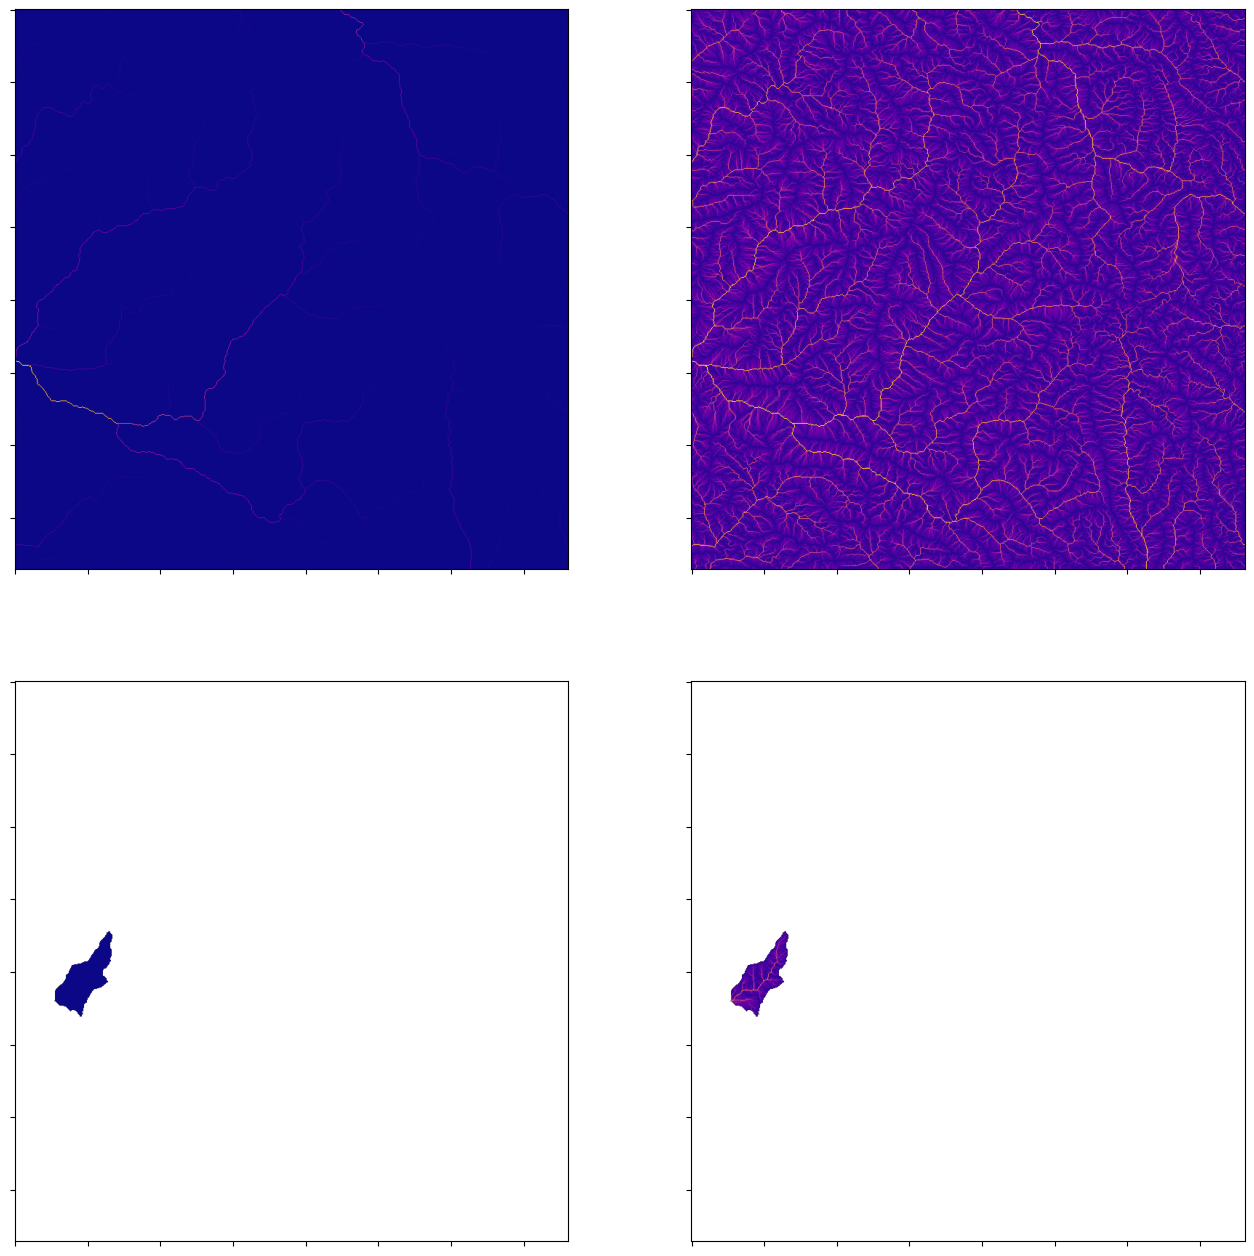

In [27]:
# Visualización
fig, ax = plt.subplots(2, 2, figsize=(16, 16))
ax[0,0].imshow(np.where(~flats, acc + 1, np.nan), zorder=1, cmap='plasma')
ax[0,1].imshow(np.where(~flats, acc + 1, np.nan), zorder=1, cmap='plasma',
               norm=colors.LogNorm(vmin=1, vmax=acc.max()))
ax[1,0].imshow(np.where(catch, catch, np.nan), zorder=1, cmap='plasma')
ax[1,1].imshow(np.where(catch, acc + 1, np.nan), zorder=1, cmap='plasma',
               norm=colors.LogNorm(vmin=1, vmax=acc.max()))

for i in range(ax.size):
    ax.flat[i].set_yticklabels([])
    ax.flat[i].set_xticklabels([])

In [28]:

fig, ax = plt.subplots()
streamNet.plot(ax=ax, color='blue')
mplleaflet.display(fig=fig, epsg=4326, tiles='esri_aerial')

/home/juanguerrero09/dev/dampy/.venv/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/juanguerrero09/dev/dampy/.venv/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


AttributeError: 'XAxis' object has no attribute '_gridOnMajor'

In [ ]:
threshold = 1000
# Paso 1: Identificar celdas con acumulación alta
pour_points = np.argwhere((acc > threshold) & (~acc.mask))

# Paso 2: Crear una matriz para almacenar las cuencas etiquetadas
catchments = np.zeros(acc.shape, dtype=np.int32)

# Paso 3: Iterar sobre los puntos y delinear cuencas
label = 1
for y, x in pour_points:
    try:
        # Delinear la cuenca para cada punto de vertido
        catch = grid.catchment(x=x, y=y, fdir=fdir, xytype='index', nodata_out=0)
        # Etiquetar las celdas de la cuenca con el número de etiqueta actual
        catchments[catch.view(np.bool_)] = label
        label += 1
    except Exception as e:
        print(f"Error processing pour point at ({x}, {y}): {e}")
        continue  # Ignorar errores por puntos inválidos

plt.figure(figsize=(10, 8))
plt.imshow(np.where(catchments > 0, catchments, np.nan), cmap='tab20')
plt.title('Todas las cuencas delineadas')
plt.colorbar(label='ID de cuenca')
plt.grid(True)
plt.show()